# theta_interpretation: averaged-regularized-theta analysis

Loads several seeds of the two `theta_interpretation` runs (`terms=['x2']`
correct vs. `terms=['x2', 'x4']` misspecified) and reduces each model to a
single number: **`theta_avg`, the mean of `Theta_reg[-1]` (the final
regularized theta) across seeds.** Every result below -- normalization
constant, rare/typical event probabilities, samples, energy components,
`log p_theta(x)` -- is computed from that single `theta_avg`, not
per-seed and then aggregated.

This is a deliberate simplification from earlier versions of this
notebook, which computed `log_Z`/tail probabilities/etc. per seed (for
both raw `theta_t[-1]` and regularized `Theta_reg[-1]`) and only averaged
the *results* afterward. Averaging the raw theta values first and
evaluating everything else once, downstream, is what's wanted now --
`theta_t[-1]` (unregularized) and the MGD lower bound (`log_Z_bound`) are
dropped entirely, since neither has a meaningful "theta_avg" analog.

This notebook only *defines and runs* the analysis -- it generates its own
data and calls the real SDE solver via `run_SDE.py`'s `run_and_diagnose()`,
so running it end-to-end does real (if small, CPU-cheap) MGD fits;
nothing here is precomputed or faked.


In [2]:
import sys
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.stats import norm, chi2

root = Path.cwd()
if not (root / 'run_SDE.py').exists():
    root = root / 'theta_interpretation'  # allow running the notebook from the repo root
sys.path.insert(0, str(root))
sys.path.insert(0, str(root.parent / 'codes'))

from run_SDE import make_args, run_and_diagnose, get_scalar_potentials, device

# run_SDE.py sets matplotlib.use('Agg') at import time (needed for its own
# headless script use) -- that silently kills inline display here, so switch
# back after importing from it.
%matplotlib inline

print('device:', device)


device: cuda


## 1. Config and multi-seed runs

`N_SEEDS` independent seeds per potential set. Every `make_args` field is
stated explicitly in `PARAM_OVERRIDES`/`LABELS` below, not left to
silently fall back to `make_args`'s own defaults in `run_SDE.py` --
`build_config_name()`/`build_group_name()` (`codes/utils_experiment.py`)
don't encode `regularization`/`n_subsample`/`n_bins`/`schedule_exponent`/
`interpolant`/`moment_threshold` in the saved config name at all -- only
`label` (plus `n1`/`sigma`/`nt`/`lam`/`terms`) does. So a `label` mismatch
is the single most common reason a rerun with "the same" parameters fails
to find a previous multi-seed sweep on disk.

`run_and_diagnose()` (via `resolve_or_setup_experiment_output` inside it)
already loads a cached run instead of refitting whenever `force_rerun` is
`False` and every one of these fields matches a previous run's saved
config exactly.

Change `PARAM_OVERRIDES`/`LABELS`/`N_SEEDS` here for a different sweep.


In [ ]:
N_SEEDS = 100
DATA_SIGMA = 1.0
TERM_SETS = {
    'correct (x2)': ['x2'],
    'misspecified (x2, x4)': ['x2', 'x4'],
}
# label per TERM_SETS entry -- must match the label a past sweep was saved
# under (see markdown above); label is NOT implied by `terms` alone.
LABELS = {
    'correct (x2)': 'sweep_x2',
    'misspecified (x2, x4)': 'sweep_x2x4',
}

# Every other make_args field, stated explicitly (see markdown above for
# why silently trusting make_args's own defaults broke loading past runs).
PARAM_OVERRIDES = dict(
    n1=50000, nt=1000, sigma=1.0, schedule_exponent=2, interpolant='Cos',
    regularization=0.001, lam=1e-08, n_subsample=1, batch_size=None,
    n_bins=30, moment_threshold=1e-8, force_rerun=False,
    no_save_aux_moments=False,
)

runs = {label: {} for label in TERM_SETS}
for label, terms in TERM_SETS.items():
    for seed in range(N_SEEDS):
        args = make_args(terms, data_sigma=DATA_SIGMA, seed=seed, outdir=str(root),
                          label=LABELS[label], **PARAM_OVERRIDES)
        runs[label][seed] = run_and_diagnose(args, outdir=root)
    print(f"{label}: {N_SEEDS} seeds done")


2026-09-21 18:33:38  INFO      Reusing existing experiment: thetainterp_sigmadata1.0_sigma1.0_nt1000_n1_50000_lam1e-08_seed_0_terms8e683187_sweep_x2_20260904_1144 (no new folder created)
2026-09-21 18:33:39  INFO      Final theta (order matches ['x2']): [0.42012977600097656]
2026-09-21 18:33:39  INFO      Reference (unverified against this run): for target N(0, data_sigma^2) under p(x) ~ exp(sum_i theta_i * phi_i(x)), theta on x^2 is expected near -0.500000. Fitted theta_x2[-1] = 0.420130
2026-09-21 18:33:39  INFO      Saved diagnostic figures to /lustre/fswork/projects/rech/wbg/ukv59en/MGD-for-Maximum-Entropy-Generation/theta_interpretation/experiments/thetainterp_sigmadata1.0_sigma1.0_nt1000_n1_50000_lam1e-08_terms8e683187_sweep_x2/thetainterp_sigmadata1.0_sigma1.0_nt1000_n1_50000_lam1e-08_seed_0_terms8e683187_sweep_x2_20260904_1144/figures
2026-09-21 18:33:40  INFO      Reusing existing experiment: thetainterp_sigmadata1.0_sigma1.0_nt1000_n1_50000_lam1e-08_seed_1_terms8e683187_sweep

/lustre/fswork/projects/rech/wbg/ukv59en/MGD-for-Maximum-Entropy-Generation/theta_interpretation/run_SDE.py:332: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.savefig(fig_dir / 'marginal_histogram.png', dpi=150, bbox_inches='tight')


## 2. Average `Theta_reg[-1]` across seeds

For each of the `N_SEEDS` seeds, take the final regularized theta,
`Theta_reg[-1]`; `theta_avg` is their mean, per potential set. The
histograms below show the per-seed spread being averaged over (target
`theta_x2 = -1/(2*data_sigma^2)`, from matching the quadratic term of
`-log N(0, data_sigma^2)`, marked for reference -- convergence to it is
not assumed elsewhere in this notebook, only checked here).


In [ ]:
REG_FINAL = {label: {} for label in TERM_SETS}
for label in TERM_SETS:
    for seed, run in runs[label].items():
        REG_FINAL[label][seed] = run['result']['Theta_reg'][-1].detach().cpu().numpy()

target_theta_x2 = -1.0 / (2 * DATA_SIGMA ** 2)

fig, axes = plt.subplots(1, len(TERM_SETS), figsize=(6 * len(TERM_SETS), 4), squeeze=False)
axes = axes[0]
THETA_AVG = {}
for ax, (label, terms) in zip(axes, TERM_SETS.items()):
    term_names = list(get_scalar_potentials(terms).keys())
    mat = np.stack([REG_FINAL[label][s] for s in sorted(REG_FINAL[label])])  # (n_seeds, n_coef)
    THETA_AVG[label] = mat.mean(axis=0)

    for i, name in enumerate(term_names):
        ax.hist(mat[:, i], bins=15, alpha=0.5, label=f'Theta_reg_{name}')
    ax.axvline(target_theta_x2, color='k', ls='--', label='target theta_x2')
    ax.axvline(0, color='grey', lw=0.5)
    ax.set_title(label); ax.set_xlabel('final Theta_reg value (per seed)'); ax.legend()

    print(f"--- {label} ---")
    for i, name in enumerate(term_names):
        col = mat[:, i]
        print(f"  {name}: mean={col.mean():+.4f}  std={col.std(ddof=1):.4f}  "
              f"min={col.min():+.4f}  max={col.max():+.4f}")
        print(f"Noise to signal ratios") 
        print(f"{name}: ratio={(col.mean()/col.std(ddof=1)):+.4f}\n")
    
    print(f"  theta_avg = {np.round(THETA_AVG[label], 4)}  (over {mat.shape[0]} seeds)\n")

    print(f"Noise to signal ratios") 
    print(f"{name}: ratio={(col.mean()/col.std(ddof=1)):+.4f}\n")
fig.tight_layout()
plt.show()


## Distribition of the shift $\Delta \theta_2$ between correct and overparametrized model 

mean = -0.027236
variance = 0.086515


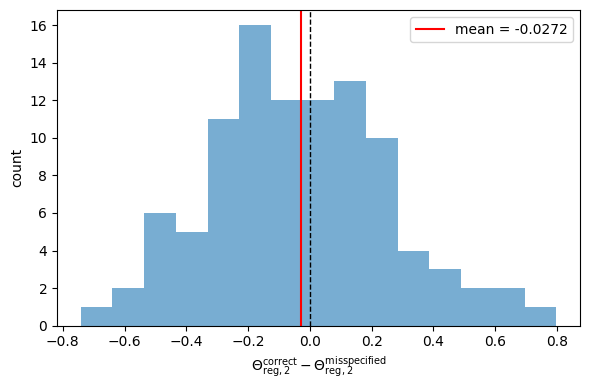

In [10]:
# theta_2 difference: correct model - misspecified model
correct = REG_FINAL['correct (x2)']
misspec = REG_FINAL['misspecified (x2, x4)']

seeds = sorted(set(correct) & set(misspec))
diff = np.array([correct[s][0] - misspec[s][0] for s in seeds])

print(f"mean = {diff.mean():+.6f}")
print(f"variance = {diff.var(ddof=1):.6f}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(diff, bins=15, alpha=0.6)
ax.axvline(0, color='k', ls='--', lw=1)
ax.axvline(diff.mean(), color='r', lw=1.5,
           label=f'mean = {diff.mean():+.4f}')
ax.set_xlabel(r'$\Theta_{\rm reg,2}^{\rm correct} - \Theta_{\rm reg,2}^{\rm misspecified}$')
ax.set_ylabel('count')
ax.legend()
fig.tight_layout()
plt.show()

## 3. Normalization constant at `theta_avg` (`log_Z_quad`)

Exact normalizer of `exp(theta_avg^T phi(x))` via 1D quadrature (sign
convention: `p(x) ~ exp(+theta^T phi(x))`, matching
`codes/utils_entropy.py`'s sign-convention audit). Compared against the
analytic ground truth `log_Z_analytic = 0.5*log(2*pi*data_sigma^2)`,
since the data really is `N(0, data_sigma^2)`.

`_is_normalizable` is a heuristic: `exp(theta^T phi)` is integrable iff
the highest-degree term with a nonzero coefficient has even degree and a
negative coefficient. For `terms=['x2','x4']` this means `theta_x4 < 0`.


In [11]:
def _degree(term):
    return int(term[1:])  # 'x2' -> 2, 'x4' -> 4

def log_p_unnorm(x, theta, term_names):
    return sum(theta[i] * x ** _degree(t) for i, t in enumerate(term_names))

def _is_normalizable(theta, term_names):
    """exp(theta^T phi) is integrable iff the highest-degree term with a
    nonzero coefficient has even degree and a negative coefficient."""
    live = [(_degree(t), theta[i])
            for i, t in enumerate(term_names) if theta[i] != 0.0]
    if not live:
        return False                      # constant, infinite mass
    deg, coef = max(live)
    return deg % 2 == 0 and coef < 0

def log_Z_quad(theta, term_names, x_range=(-50.0, 50.0)):
    """Exact normalizer of exp(theta^T phi(x)) via 1D quadrature."""
    if not _is_normalizable(theta, term_names):
        return float('nan')
    grid = np.linspace(*x_range, 4001)
    log_vals = log_p_unnorm(grid, theta, term_names)
    m = log_vals.max()
    support = grid[log_vals - m > -700.0]          # everything else underflows
    lo, hi = support[0], support[-1]
    modes = list(grid[1:-1][(log_vals[1:-1] > log_vals[:-2]) &
                            (log_vals[1:-1] > log_vals[2:])])
    val, _ = quad(lambda x: np.exp(log_p_unnorm(x, theta, term_names) - m),
                  lo, hi, points=modes, limit=200)
    return m + np.log(val)

def log_tail_probability(theta, term_names, log_Z, a, b=np.inf):
    """log P(a < X < b) under exp(theta^T phi(x)) / Z. Bounds quad to the
    same truncated interval used to locate the integrand's peak, which
    avoids the roundoff-driven negative `val` (-> nan) that a literal
    a/b range can hit on thin tails."""
    if not np.isfinite(log_Z):
        return float('nan')
    hi = min(b, a + 50.0) if not np.isfinite(b) else b
    lo = max(a, -50.0) if not np.isfinite(a) else a
    s = log_p_unnorm(np.linspace(lo, hi, 2001), theta, term_names).max()
    val, _ = quad(lambda x: np.exp(log_p_unnorm(x, theta, term_names) - s),
                  lo, hi, points=[lo, hi], limit=200)
    if val <= 0:
        return float('-inf')          # genuinely below quad's resolution, not undefined
    return s + np.log(val) - log_Z


In [12]:
log_Z_analytic = 0.5 * np.log(2 * np.pi * DATA_SIGMA ** 2)
print(f"log_Z_analytic = {log_Z_analytic:.4f}\n")

LOG_Z_AVG = {}
for label, terms in TERM_SETS.items():
    term_names = list(get_scalar_potentials(terms).keys())
    LOG_Z_AVG[label] = log_Z_quad(THETA_AVG[label], term_names)
    status = f"{LOG_Z_AVG[label]:.4f}" if np.isfinite(LOG_Z_AVG[label]) else "nan (non-normalizable)"
    print(f"{label:>22s}  log_Z_quad(theta_avg) = {status}   "
          f"(fit error vs. analytic: {log_Z_analytic - LOG_Z_AVG[label]:+.4f})")


log_Z_analytic = 0.9189

          correct (x2)  log_Z_quad(theta_avg) = 0.9309   (fit error vs. analytic: -0.0119)
 misspecified (x2, x4)  log_Z_quad(theta_avg) = 0.9434   (fit error vs. analytic: -0.0245)


## 4. Rare-event vs. typical-event probability, at `theta_avg`

Rare event: `|X| > 4*data_sigma`. Typical event: `|X| < 1*data_sigma`.
Both computed under the density `theta_avg` actually defines (using
`LOG_Z_AVG` from section 3), and compared to the exact analytic values
under the true `N(0, data_sigma^2)`.


In [13]:
RARE_THRESHOLD = 4 * DATA_SIGMA
TYPICAL_THRESHOLD = 1 * DATA_SIGMA

P_rare_true = 2 * norm.sf(RARE_THRESHOLD / DATA_SIGMA)             # two-sided |X| > 4 sigma
P_typical_true = 2 * norm.cdf(TYPICAL_THRESHOLD / DATA_SIGMA) - 1  # |X| < 1 sigma
print(f"True (analytic) P(|X| > {RARE_THRESHOLD}) = {P_rare_true:.6e}")
print(f"True (analytic) P(|X| < {TYPICAL_THRESHOLD}) = {P_typical_true:.6e}\n")

for label, terms in TERM_SETS.items():
    term_names = list(get_scalar_potentials(terms).keys())
    theta_avg, lZ_avg = THETA_AVG[label], LOG_Z_AVG[label]
    if not np.isfinite(lZ_avg):
        print(f"{label}: theta_avg non-normalizable, skipping")
        continue

    log_p_upper = log_tail_probability(theta_avg, term_names, lZ_avg, RARE_THRESHOLD, np.inf)
    log_p_lower = log_tail_probability(theta_avg, term_names, lZ_avg, -np.inf, -RARE_THRESHOLD)
    P_rare = np.exp(np.logaddexp(log_p_upper, log_p_lower))       # log(P_upper + P_lower)
    P_typ = np.exp(log_tail_probability(theta_avg, term_names, lZ_avg,
                                         -TYPICAL_THRESHOLD, TYPICAL_THRESHOLD))

    print(f"--- {label} (theta_avg) ---")
    print(f"  P(|X| > {RARE_THRESHOLD})  = {P_rare:.6e}   (true: {P_rare_true:.6e})")
    print(f"  P(|X| < {TYPICAL_THRESHOLD})  = {P_typ:.6e}   (true: {P_typical_true:.6e})")


True (analytic) P(|X| > 4.0) = 6.334248e-05
True (analytic) P(|X| < 1.0) = 6.826895e-01

--- correct (x2) (theta_avg) ---
  P(|X| > 4.0)  = 7.734279e-05   (true: 6.334248e-05)
  P(|X| < 1.0)  = 6.769071e-01   (true: 6.826895e-01)
--- misspecified (x2, x4) (theta_avg) ---
  P(|X| > 4.0)  = 2.568675e-05   (true: 6.334248e-05)
  P(|X| < 1.0)  = 6.732788e-01   (true: 6.826895e-01)


## 5. Samples from the `theta_avg` fit

`sample_from_fit` draws i.i.d. samples by inverse-CDF on a fine grid,
self-normalizing (doesn't use `log_Z`). Only called on `theta_avg` when
section 3 found it normalizable.


In [14]:
def sample_from_fit(theta, term_names, n, rng, x_range=(-50.0, 50.0), n_grid=200_001):
    """i.i.d. draws from exp(theta^T phi(x)) / Z by inverse-CDF on a fine
    grid. Self-normalizing: does not use log_Z. Only call on theta whose
    density is normalizable, otherwise the grid truncation silently
    defines the distribution."""
    grid = np.linspace(*x_range, n_grid)
    lv = log_p_unnorm(grid, theta, term_names)
    keep = lv - lv.max() > -700.0                    # everything else underflows
    grid = np.linspace(grid[keep][0], grid[keep][-1], n_grid)   # re-grid on support
    lv = log_p_unnorm(grid, theta, term_names)
    dens = np.exp(lv - lv.max())

    cdf = np.concatenate([[0.0], np.cumsum(0.5 * (dens[1:] + dens[:-1]) * np.diff(grid))])
    cdf /= cdf[-1]
    uniq = np.concatenate([[True], np.diff(cdf) > 0])            # np.interp needs increasing
    return np.interp(rng.random(n), cdf[uniq], grid[uniq])

def gaussianity_stats(x):
    """Moment-based non-Gaussianity summary. Excess kurtosis is 0 for a
    Gaussian; bimodality drives it negative, heavy tails positive."""
    mu, sd = x.mean(), x.std(ddof=1)
    z = (x - mu) / sd
    return {'mean': mu, 'std': sd,
            'skew': float((z ** 3).mean()),
            'excess_kurt': float((z ** 4).mean() - 3.0)}

N_SAMPLES = 200_000
rng = np.random.default_rng(0)

SAMPLES_AVG, STATS_AVG = {}, {}
for label, terms in TERM_SETS.items():
    term_names = list(get_scalar_potentials(terms).keys())
    theta_avg, lZ_avg = THETA_AVG[label], LOG_Z_AVG[label]
    if not np.isfinite(lZ_avg):
        print(f"  skipping {label}: theta_avg non-normalizable")
        SAMPLES_AVG[label] = None
        continue
    x = sample_from_fit(theta_avg, term_names, N_SAMPLES, rng)
    SAMPLES_AVG[label] = x
    STATS_AVG[label] = gaussianity_stats(x)
    s = STATS_AVG[label]
    print(f"{label:>22s}  theta_avg={np.round(theta_avg, 4)}  "
          f"mean={s['mean']:+.3f}  std={s['std']:.3f}  "
          f"skew={s['skew']:+.3f}  excess_kurt={s['excess_kurt']:+.3f}")


          correct (x2)  theta_avg=[-0.4882]  mean=-0.003  std=1.011  skew=+0.001  excess_kurt=+0.022
 misspecified (x2, x4)  theta_avg=[-0.461 -0.005]  mean=+0.002  std=1.012  skew=+0.006  excess_kurt=-0.108


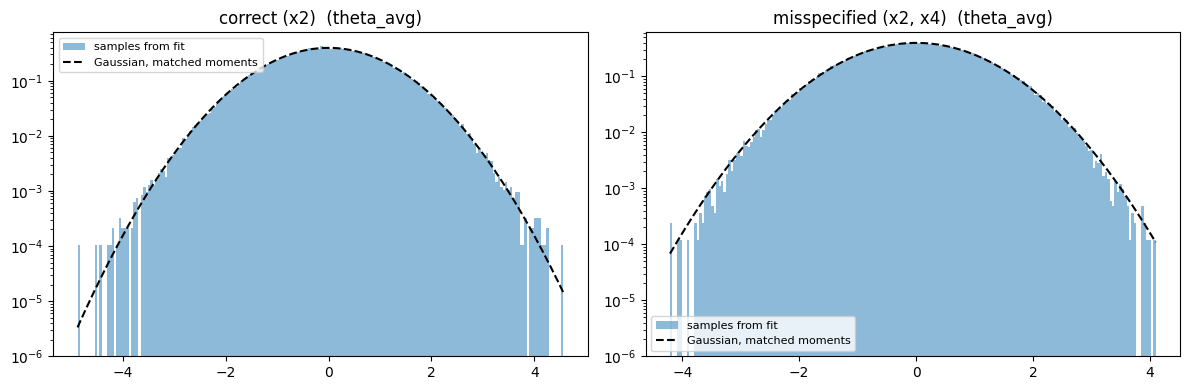

In [15]:
fig, axes = plt.subplots(1, len(TERM_SETS), figsize=(6 * len(TERM_SETS), 4), squeeze=False)
axes = axes[0]
for ax, label in zip(axes, TERM_SETS):
    x = SAMPLES_AVG[label]
    ax.set_title(f'{label}  (theta_avg)')
    if x is None:
        ax.text(0.5, 0.5, 'non-normalizable fit\n(skipped)', ha='center', va='center', transform=ax.transAxes)
        continue
    grid = np.linspace(x.min(), x.max(), 1000)
    ax.hist(x, bins=200, density=True, alpha=0.5, label='samples from fit')
    ax.plot(grid, norm.pdf(grid, x.mean(), x.std(ddof=1)), 'k--', label='Gaussian, matched moments')
    ax.set_yscale('log')                      # tails are the discriminating region
    ax.set_ylim(1e-6, None)
    ax.legend(fontsize=8)
fig.tight_layout()
plt.show()


## 6. Per-component energy and `log p_theta(x)`, at `theta_avg`

For each term `x^k`, the per-sample "energy component" `theta_k * x^k`
-- one summand of `theta^T phi(x) = sum_k theta_k * x^k` -- computed on
samples drawn from `theta_avg`. For the correct (`x2`) model, `theta2 *
X^2` has an exact, parameter-free reference density (`-0.5*chi2(1)`,
rescaled): a direct check that the fit's own samples match what its own
`theta_avg` predicts. For the misspecified (`x2, x4`) model, `theta4 *
X^4` is compared to what that `theta4` would produce if the data were
exactly `N(0, data_sigma^2)` (the true law, not the fit's own) -- NOT a
self-consistency check like the `x2` case, but a measure of how much the
`x^4` term reshapes the density relative to the truth.


          correct (x2)  theta_x2*x^2: mean=-0.4986  std=0.7089
 misspecified (x2, x4)  theta_x2*x^2: mean=-0.4719  std=0.6492
 misspecified (x2, x4)  theta_x4*x^4: mean=-0.0151  std=0.0460


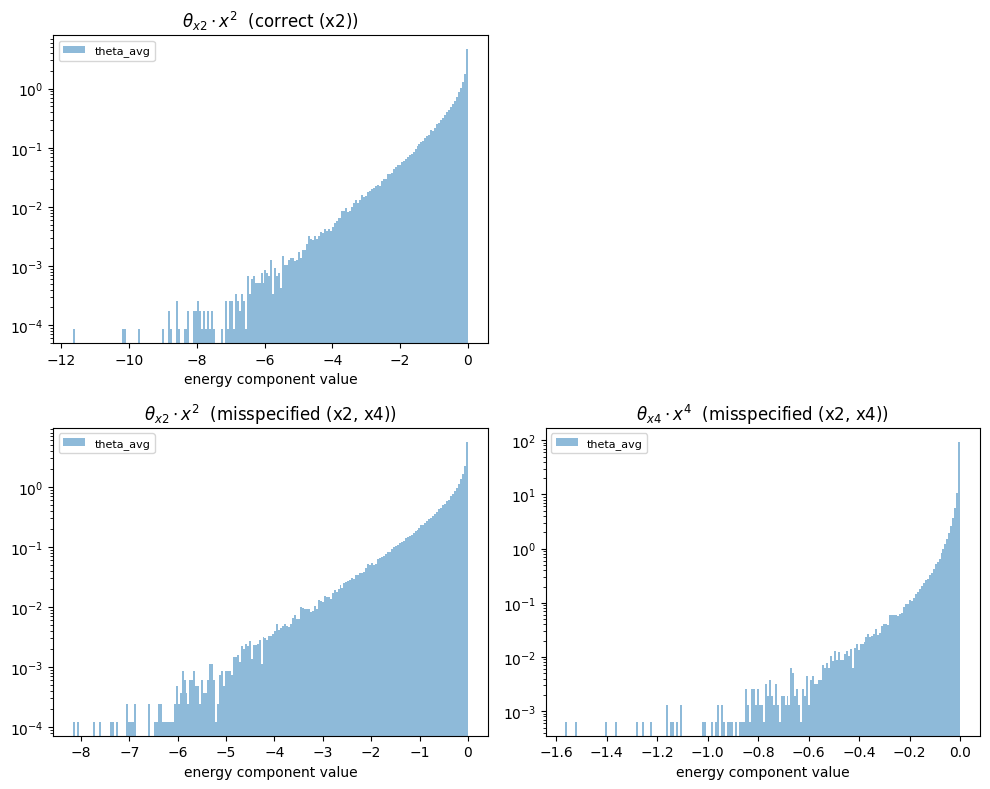

In [16]:
def energy_components(x, theta, term_names):
    """theta_k * x**k for each term -- one summand of theta^T phi(x)."""
    return {name: theta[i] * x ** _degree(name) for i, name in enumerate(term_names)}

n_cols = max(len(get_scalar_potentials(terms).keys()) for terms in TERM_SETS.values())
fig, axes = plt.subplots(len(TERM_SETS), n_cols, figsize=(5 * n_cols, 4 * len(TERM_SETS)), squeeze=False)
for r, (label, terms) in enumerate(TERM_SETS.items()):
    term_names = list(get_scalar_potentials(terms).keys())
    x = SAMPLES_AVG[label]
    for c, name in enumerate(term_names):
        ax = axes[r][c]
        if x is None:
            print(f"{label}: no samples, skipping")
        else:
            comp = energy_components(x, THETA_AVG[label], term_names)[name]
            ax.hist(comp, bins=200, density=True, alpha=0.5, label='theta_avg')
            print(f"{label:>22s}  theta_{name}*x^{_degree(name)}: mean={comp.mean():+.4f}  std={comp.std(ddof=1):.4f}")
        ax.set_title(rf'$\theta_{{{name}}} \cdot x^{_degree(name)}$  ({label})')
        ax.set_xlabel('energy component value')
        ax.legend(fontsize=8)
        ax.set_yscale('log')
    for c in range(len(term_names), n_cols):
        axes[r][c].axis('off')
fig.tight_layout()
plt.show()


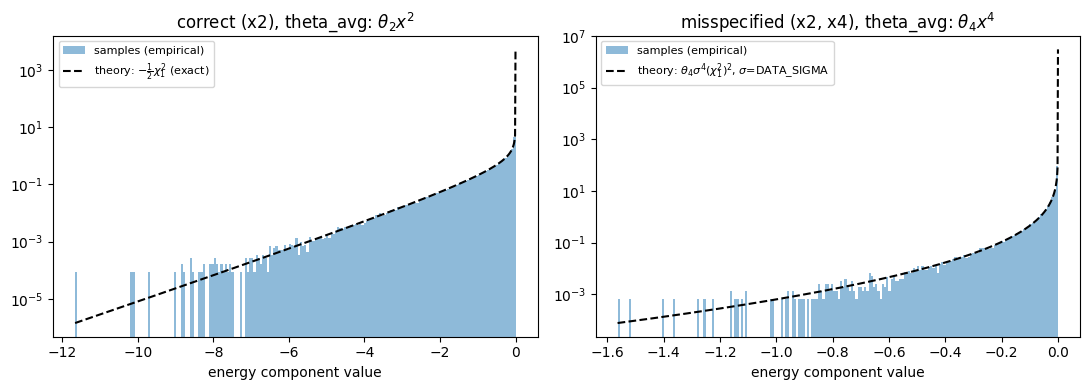

In [17]:
def theta2_component_pdf(y, theta2, sigma):
    """Exact density of Y = theta2 * X**2 for X ~ N(0, sigma**2).
    X**2 / sigma**2 ~ chi2(df=1), so Y = c*V with c = theta2*sigma**2 and
    V ~ chi2(1) -- a linear rescaling of chi2(1)."""
    c = theta2 * sigma**2
    v = y / c
    return np.where(v > 0, chi2.pdf(v, df=1) / np.abs(c), 0.0)

def theta4_component_pdf(y, theta4, sigma):
    """Exact density of Y = theta4 * X**4 for X ~ N(0, sigma**2).
    X**4 / sigma**4 = V**2 with V ~ chi2(df=1) -- the SQUARE of a chi2(1)
    variable -- so Y = c*V**2 with c = theta4*sigma**4."""
    c = theta4 * sigma**4
    w = y / c
    v = np.sqrt(np.clip(w, 0, None))
    with np.errstate(divide='ignore', invalid='ignore'):
        dens = chi2.pdf(v, df=1) / (2 * np.abs(c) * v)
    return np.where(w > 0, dens, 0.0)


fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# --- correct (x2): theta2*X^2 vs. -0.5*chi2(1), EXACT, parameter-free ---
theta2 = THETA_AVG['correct (x2)'][0]
sigma_fit = np.sqrt(-1.0 / (2 * theta2))
x_correct = SAMPLES_AVG['correct (x2)']
comp2 = theta2 * x_correct ** 2

eps2 = 1e-9 * np.abs(comp2).max()
grid2 = np.linspace(comp2.min(), -eps2, 1000)
axes[0].hist(comp2, bins=200, density=True, alpha=0.5, label='samples (empirical)')
axes[0].plot(grid2, theta2_component_pdf(grid2, theta2, sigma_fit), 'k--',
             label=r'theory: $-\frac{1}{2}\chi^2_1$ (exact)')
axes[0].set_title(r'correct (x2), theta_avg: $\theta_2 x^2$')
axes[0].set_xlabel('energy component value')
axes[0].set_yscale('log')
axes[0].legend(fontsize=8)

# --- misspecified (x2, x4): theta4*X^4 vs. what theta4 would produce
# under the TRUE data-generating law N(0, DATA_SIGMA^2) -- NOT
# self-consistent like the x2 case (see markdown above).
theta4 = THETA_AVG['misspecified (x2, x4)'][1]
x_misspec = SAMPLES_AVG['misspecified (x2, x4)']
comp4 = theta4 * x_misspec ** 4

eps4 = 1e-9 * np.abs(comp4).max()
grid4 = np.linspace(comp4.min(), -eps4, 1000) if theta4 < 0 else np.linspace(eps4, comp4.max(), 1000)
axes[1].hist(comp4, bins=200, density=True, alpha=0.5, label='samples (empirical)')
axes[1].plot(grid4, theta4_component_pdf(grid4, theta4, DATA_SIGMA), 'k--',
             label=r'theory: $\theta_4 \sigma^4 (\chi^2_1)^2$, $\sigma$=DATA_SIGMA')
axes[1].set_title(r'misspecified (x2, x4), theta_avg: $\theta_4 x^4$')
axes[1].set_xlabel('energy component value')
axes[1].set_yscale('log')
axes[1].legend(fontsize=8)

fig.tight_layout()
plt.show()


          correct (x2)  log p_theta(x): mean=-1.4295  std=0.7089
 misspecified (x2, x4)  log p_theta(x): mean=-1.4304  std=0.6899


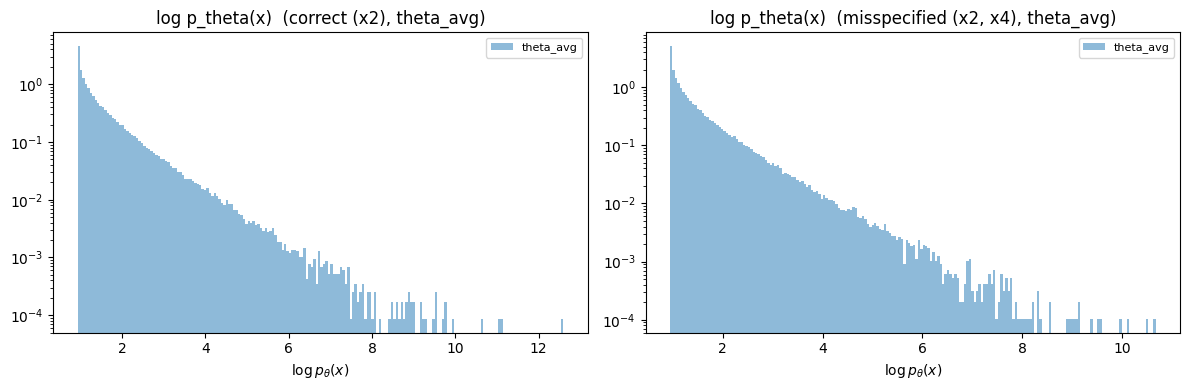

In [18]:
fig, axes = plt.subplots(1, len(TERM_SETS), figsize=(6 * len(TERM_SETS), 4), squeeze=False)
axes = axes[0]
for ax, label in zip(axes, TERM_SETS):
    x = SAMPLES_AVG[label]
    if x is None:
        ax.set_title(f'log p_theta(x)  ({label}) -- skipped')
        continue
    term_names = list(get_scalar_potentials(TERM_SETS[label]).keys())
    theta_avg, lZ_avg = THETA_AVG[label], LOG_Z_AVG[label]
    log_p = log_p_unnorm(x, theta_avg, term_names) - lZ_avg
    ax.hist(-log_p, bins=200, density=True, alpha=0.5, label='theta_avg')
    print(f"{label:>22s}  log p_theta(x): mean={log_p.mean():+.4f}  std={log_p.std(ddof=1):.4f}")
    ax.set_title(f'log p_theta(x)  ({label}, theta_avg)')
    ax.set_xlabel(r'$\log p_\theta(x)$')
    ax.legend(fontsize=8)
    ax.set_yscale('log')
fig.tight_layout()
plt.show()
